In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

In [107]:
with open("data/Foreign_Exchange_Rates.csv", "r", encoding="utf-8-sig") as f:
    lines = f.readlines()
# need to deal with the double quotes that wrap every line in the csv, formatting issue
cleaned_lines = []

for line in lines:
    line = line.rstrip("\r\n")

    if line.startswith('"') and line.endswith('"'):
        line = line[1:-1]

    cleaned_lines.append(line)

cleaned_csv = "\n".join(cleaned_lines)

df = pd.read_csv(io.StringIO(cleaned_csv))
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


In [108]:
print("Dataset shape: ", df.shape)
print("\nFirst 5 rows:\n", df.head(5))
print("\nInfo about dataset:")
df.info()


Dataset shape:  (5217, 25)

First 5 rows:
    Unnamed: 0  Time Serie AUSTRALIA - AUSTRALIAN DOLLAR/US$  \
0           0  03-01-2000                            1.5172   
1           1  04-01-2000                            1.5239   
2           2  05-01-2000                            1.5267   
3           3  06-01-2000                            1.5291   
4           4  07-01-2000                            1.5272   

  EURO AREA - EURO/US$ NEW ZEALAND - NEW ZELAND DOLLAR/US$  \
0               0.9847                              1.9033   
1                 0.97                              1.9238   
2               0.9676                              1.9339   
3               0.9686                              1.9436   
4               0.9714                               1.938   

  UNITED KINGDOM - UNITED KINGDOM POUND/US$ BRAZIL - REAL/US$  \
0                                    0.6146             1.805   
1                                    0.6109            1.8405   
2         

In [109]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Unnamed: 0                                      0
Time Serie                                      0
AUSTRALIA - AUSTRALIAN DOLLAR/US$               0
EURO AREA - EURO/US$                            0
NEW ZEALAND - NEW ZELAND DOLLAR/US$             0
UNITED KINGDOM - UNITED KINGDOM POUND/US$       0
BRAZIL - REAL/US$                               0
CANADA - CANADIAN DOLLAR/US$                    0
CHINA - YUAN/US$                                0
HONG KONG - HONG KONG DOLLAR/US$                0
INDIA - INDIAN RUPEE/US$                        0
KOREA - WON/US$                                 0
MEXICO - MEXICAN PESO/US$                       0
SOUTH AFRICA - RAND/US$                         0
SINGAPORE - SINGAPORE DOLLAR/US$                0
DENMARK - DANISH KRONE/US$                      0
JAPAN - YEN/US$                                 0
MALAYSIA - RINGGIT/US$                          0
NORWAY - NORWEGIAN KRONE/US$                    0
SWEDEN - KRONA/US$               

In [110]:
print(df.columns.tolist())

['Unnamed: 0', 'Time Serie', 'AUSTRALIA - AUSTRALIAN DOLLAR/US$', 'EURO AREA - EURO/US$', 'NEW ZEALAND - NEW ZELAND DOLLAR/US$', 'UNITED KINGDOM - UNITED KINGDOM POUND/US$', 'BRAZIL - REAL/US$', 'CANADA - CANADIAN DOLLAR/US$', 'CHINA - YUAN/US$', 'HONG KONG - HONG KONG DOLLAR/US$', 'INDIA - INDIAN RUPEE/US$', 'KOREA - WON/US$', 'MEXICO - MEXICAN PESO/US$', 'SOUTH AFRICA - RAND/US$', 'SINGAPORE - SINGAPORE DOLLAR/US$', 'DENMARK - DANISH KRONE/US$', 'JAPAN - YEN/US$', 'MALAYSIA - RINGGIT/US$', 'NORWAY - NORWEGIAN KRONE/US$', 'SWEDEN - KRONA/US$', 'SRI LANKA - SRI LANKAN RUPEE/US$', 'SWITZERLAND - FRANC/US$', 'TAIWAN - NEW TAIWAN DOLLAR/US$', 'THAILAND - BAHT/US$', 'Unnamed: 24']


In [111]:
df.drop(columns = ["Unnamed: 0", "Unnamed: 24"], inplace = True)

In [112]:
df.columns =["date", "australian dollar", "euro", "new zealand dollar", "united kingdom pound",
             "real", "canadian dollar", "yuan", "hong kong dollar", "indian rupee", "won",
             "mexican peso", "rand", "singapore dollar", "danish krone", "yen", "ringgit",
             "norwegian krone", "krona", "sri lankan rupee", "franc", "new taiwan dollar", "baht"]
# renamed the columns so easier to refer to each, these are all / USD

In [113]:
print(df.head(5))

         date australian dollar    euro new zealand dollar  \
0  03-01-2000            1.5172  0.9847             1.9033   
1  04-01-2000            1.5239    0.97             1.9238   
2  05-01-2000            1.5267  0.9676             1.9339   
3  06-01-2000            1.5291  0.9686             1.9436   
4  07-01-2000            1.5272  0.9714              1.938   

  united kingdom pound    real canadian dollar    yuan hong kong dollar  \
0               0.6146   1.805          1.4465  8.2798           7.7765   
1               0.6109  1.8405          1.4518  8.2799           7.7775   
2               0.6092   1.856          1.4518  8.2798            7.778   
3                0.607    1.84          1.4571  8.2797           7.7785   
4               0.6104   1.831          1.4505  8.2794           7.7783   

  indian rupee     won mexican peso   rand singapore dollar danish krone  \
0        43.55    1128       9.4015  6.126           1.6563        7.329   
1        43.55  1122.5  

In [114]:
df["date"] =pd.to_datetime(df["date"], format = "%d-%m-%Y")

In [115]:
print(df.select_dtypes(include = "number")) # shows that the values are not stored as numbers
# let us investigate why
print(df["australian dollar"].describe()) # so this shows that there are some 'ND' in the dataset, we must treat these as null
df.replace("ND", np.nan, inplace = True)
# now we can convert all columns from str to float except date
currency_cols = df.columns.drop("date")
df[currency_cols] = df[currency_cols].apply(pd.to_numeric)
print(df.select_dtypes(include = "number"))

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[5217 rows x 0 columns]
count     5217
unique    2959
top         ND
freq       198
Name: australian dollar, dtype: object
      australian dollar    euro  new zealand dollar  united kingdom pound  \
0                1.5172  0.9847              1.9033                0.6146   
1                1.5239  0.9700              1.9238                0.6109   
2                1.5267  0.9676              1.9339                0.6092   
3                1.5291  0.9686              1.9436                0.6070   
4                1.5272  0.9714              1.9380         

In [116]:
# now we need to deal with these missing values. let's impute using Median
imputer = SimpleImputer(strategy = "median")
df[currency_cols] = imputer.fit_transform(df[currency_cols])

In [117]:
print("Checking for missing values:\n", df.isnull().sum())

Checking for missing values:
 date                    0
australian dollar       0
euro                    0
new zealand dollar      0
united kingdom pound    0
real                    0
canadian dollar         0
yuan                    0
hong kong dollar        0
indian rupee            0
won                     0
mexican peso            0
rand                    0
singapore dollar        0
danish krone            0
yen                     0
ringgit                 0
norwegian krone         0
krona                   0
sri lankan rupee        0
franc                   0
new taiwan dollar       0
baht                    0
dtype: int64


In [118]:
# acknowledge that there aren't really outliers for forex time series analysis
# so let's make a function that plots each currency against time instead
def plot_currency_against_time(df, col):
    df.plot(figsize = (15,5), x = "date", y = col)
    plt.xlabel("Date")
    plt.ylabel(col + " / USD")
    plt.show()

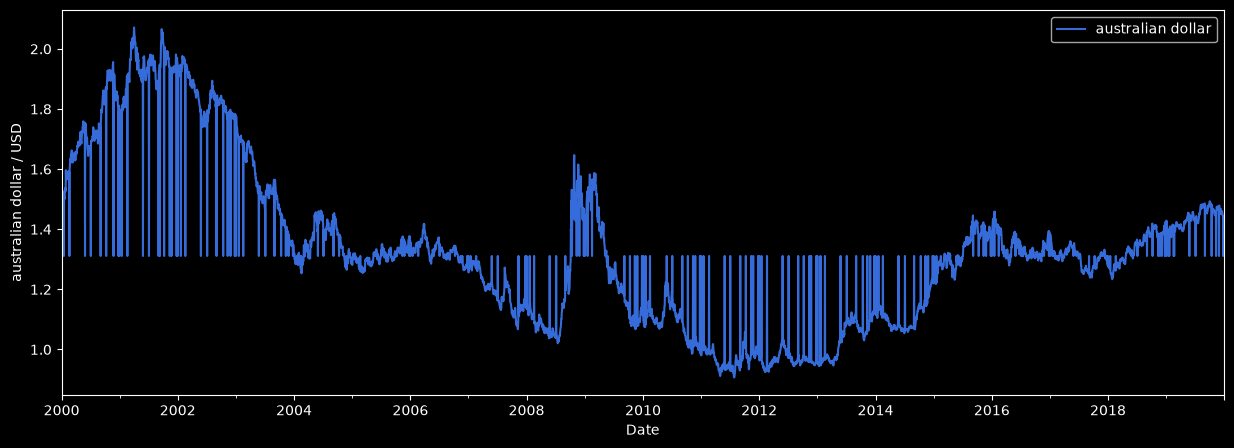

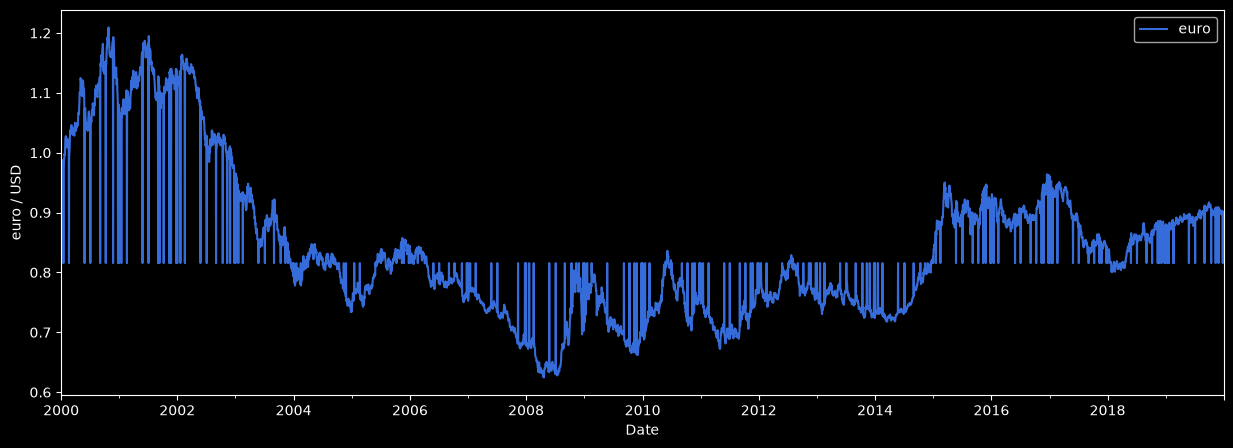

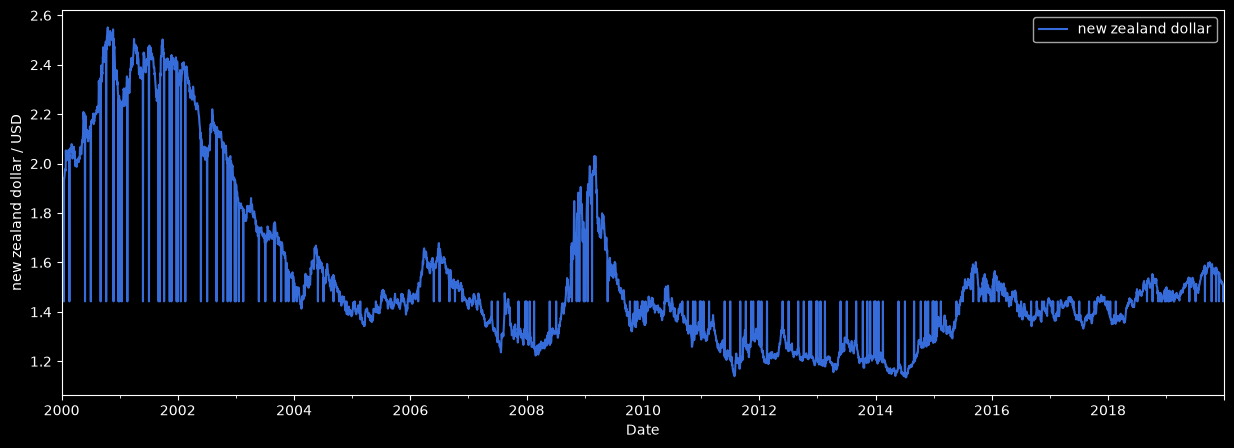

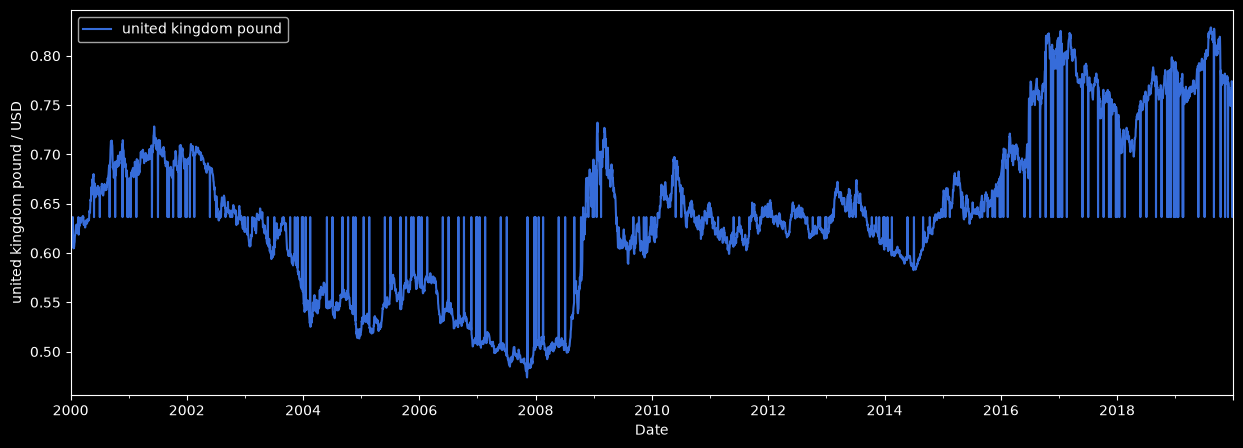

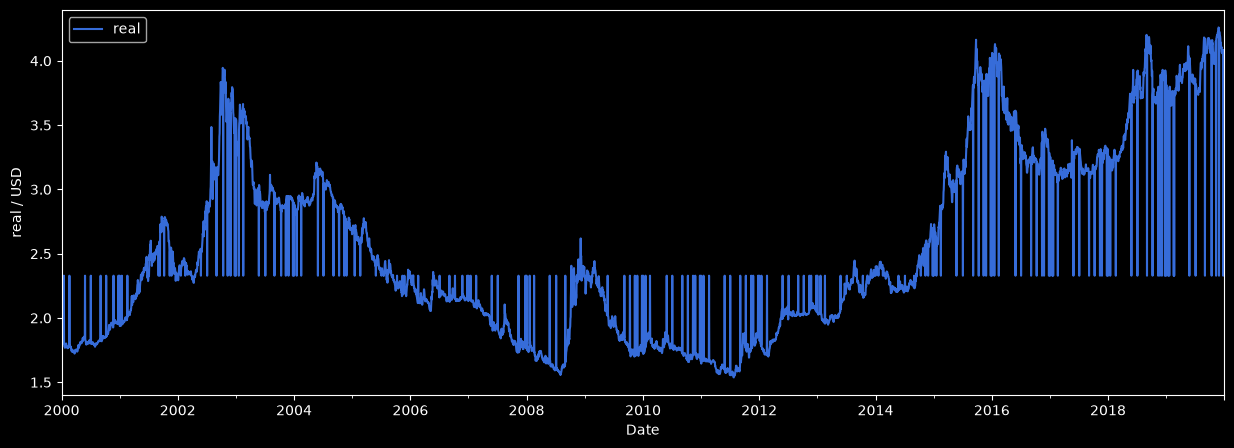

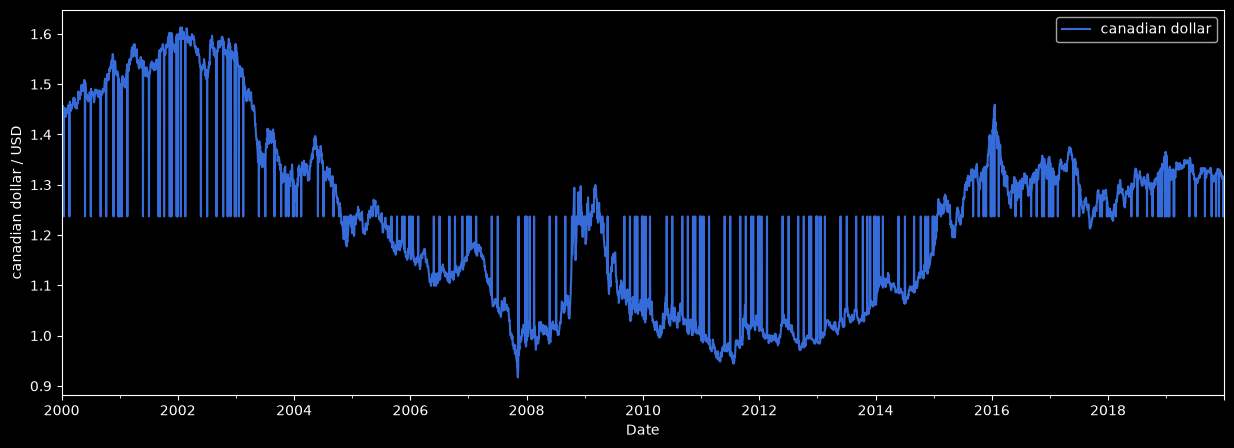

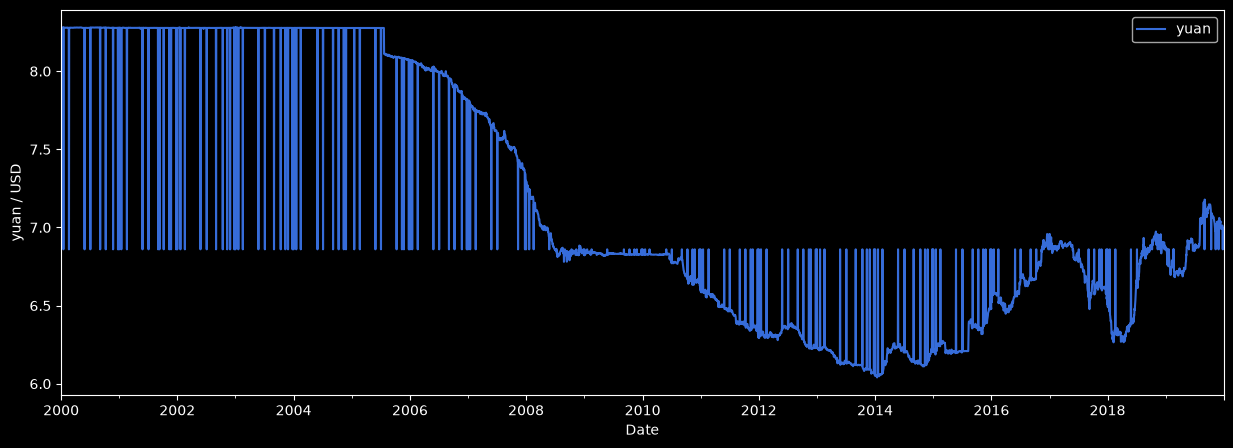

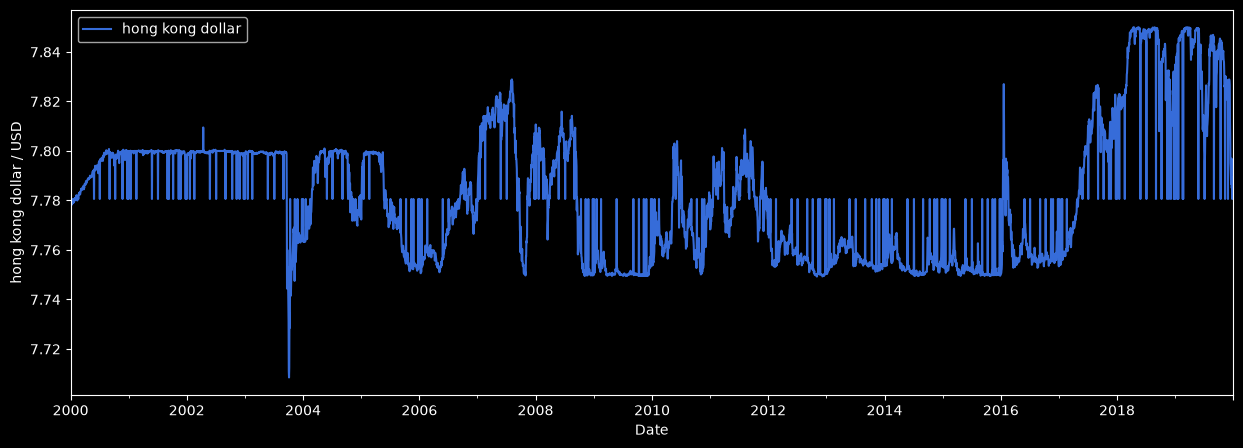

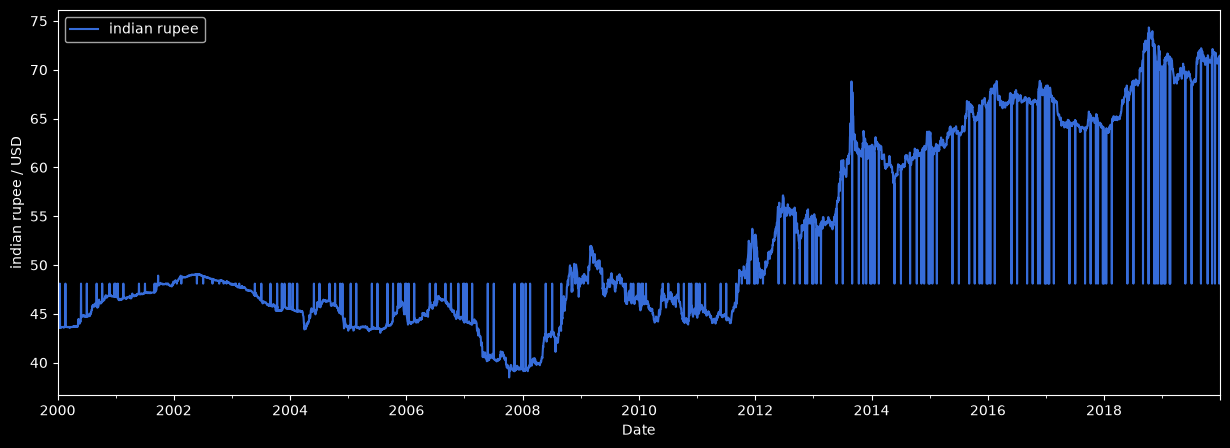

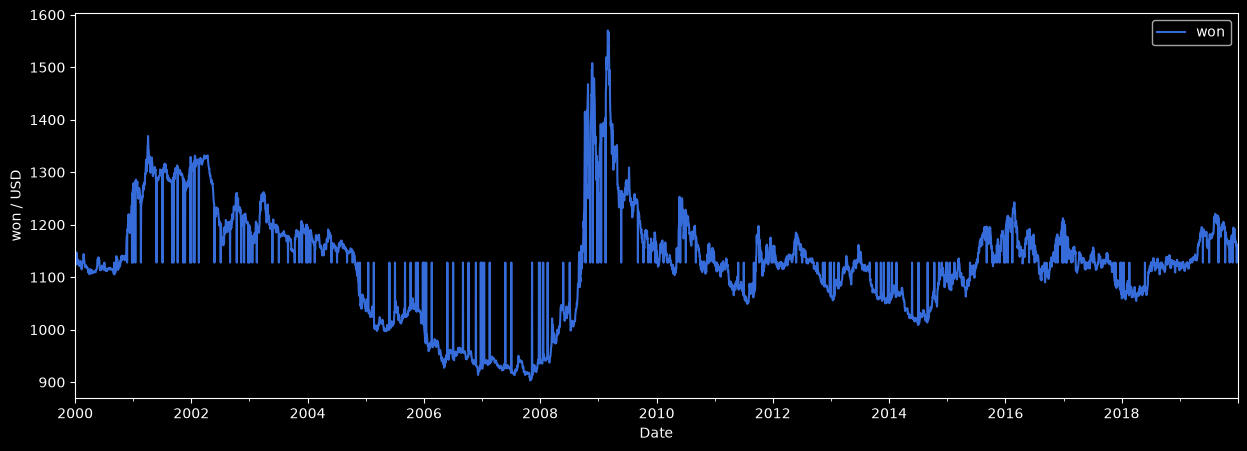

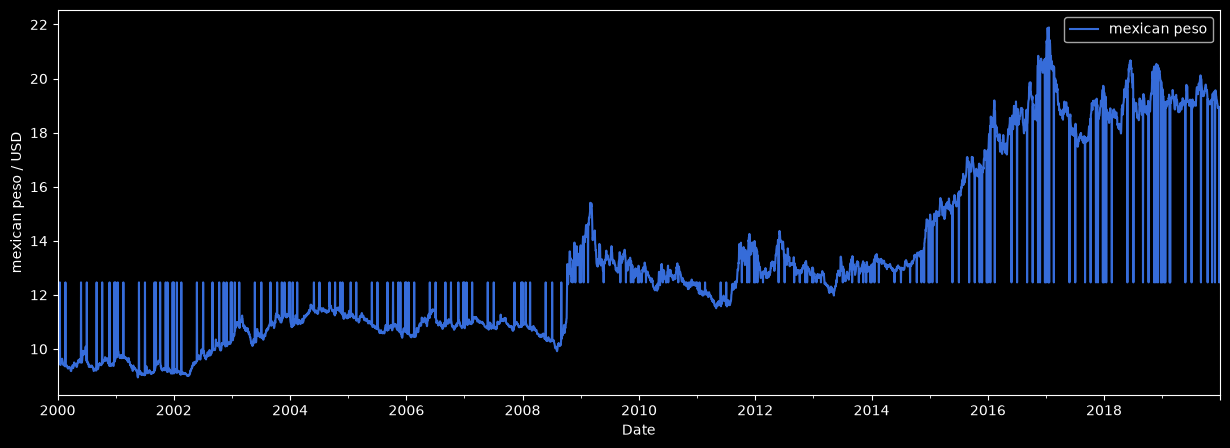

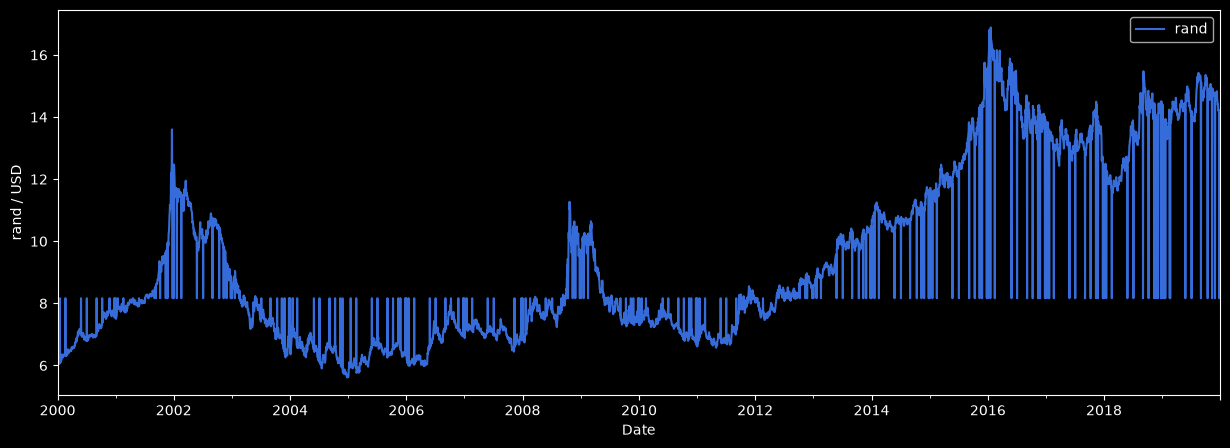

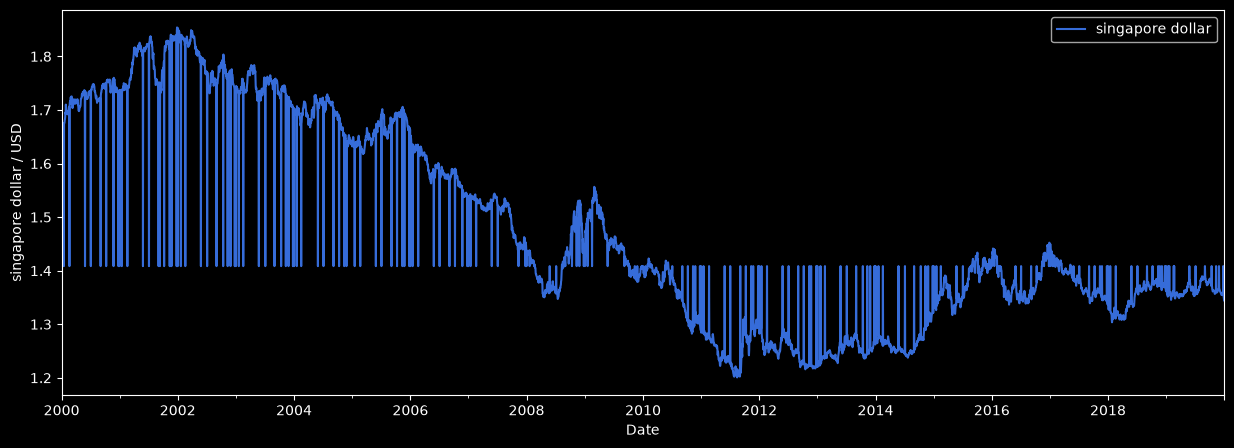

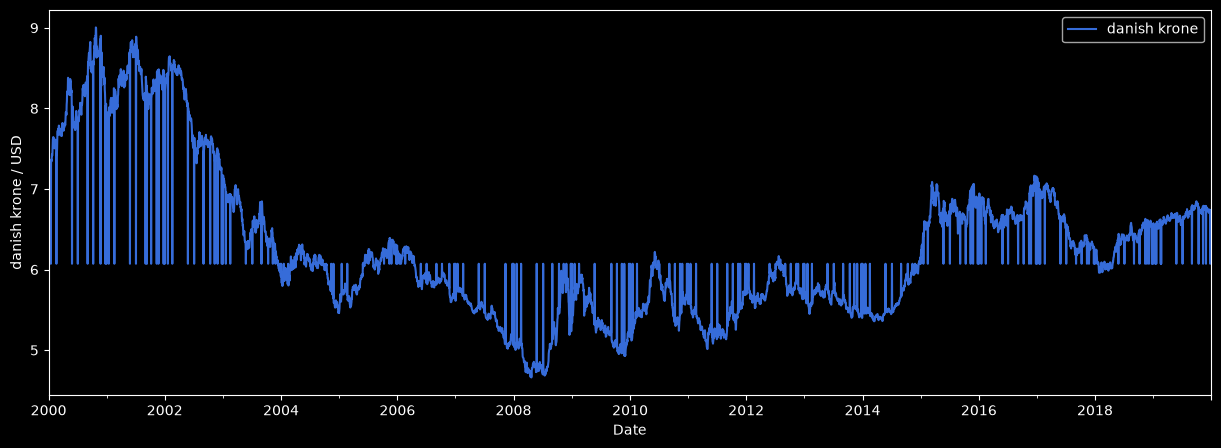

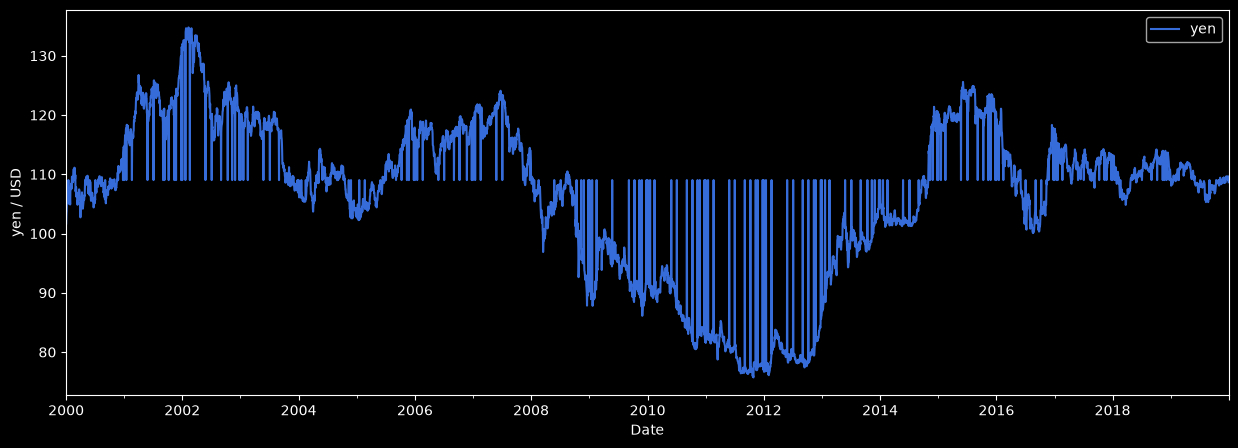

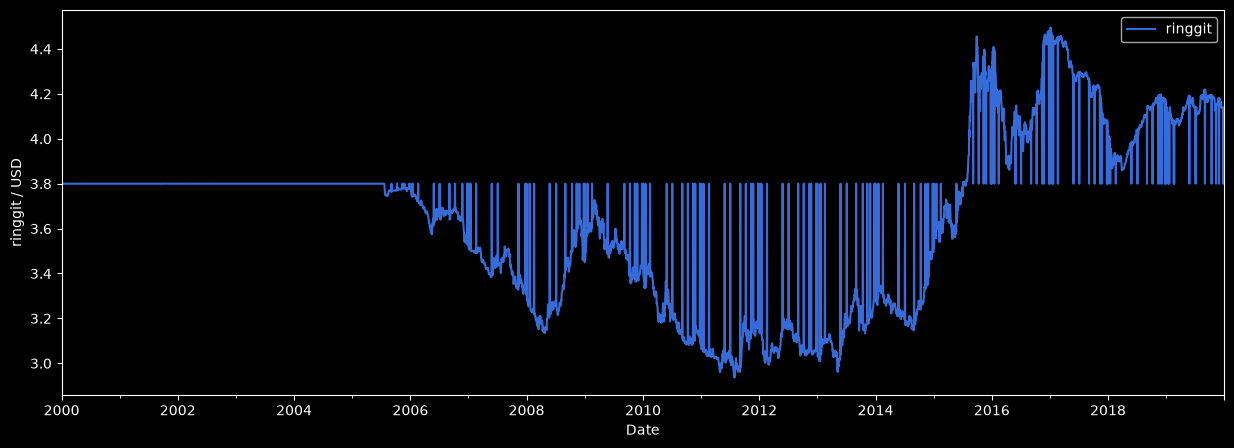

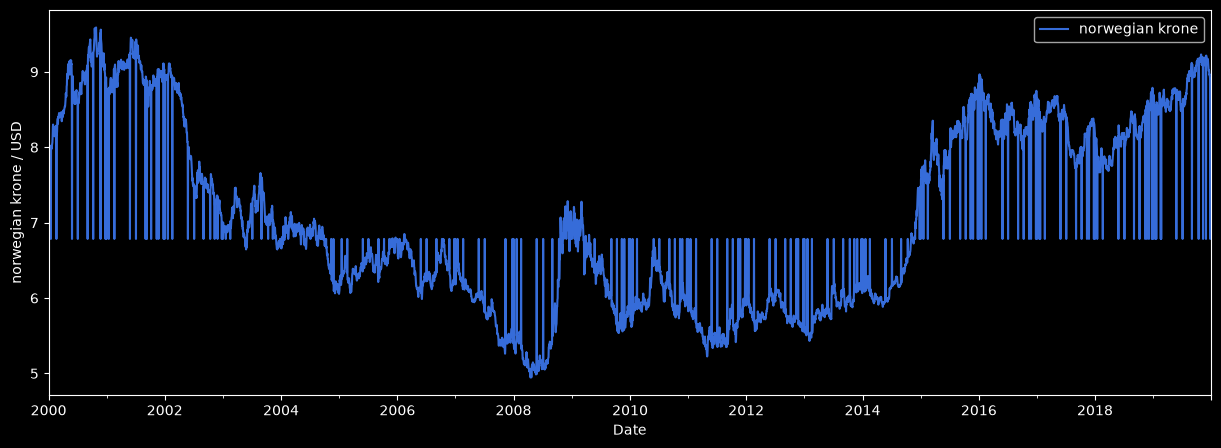

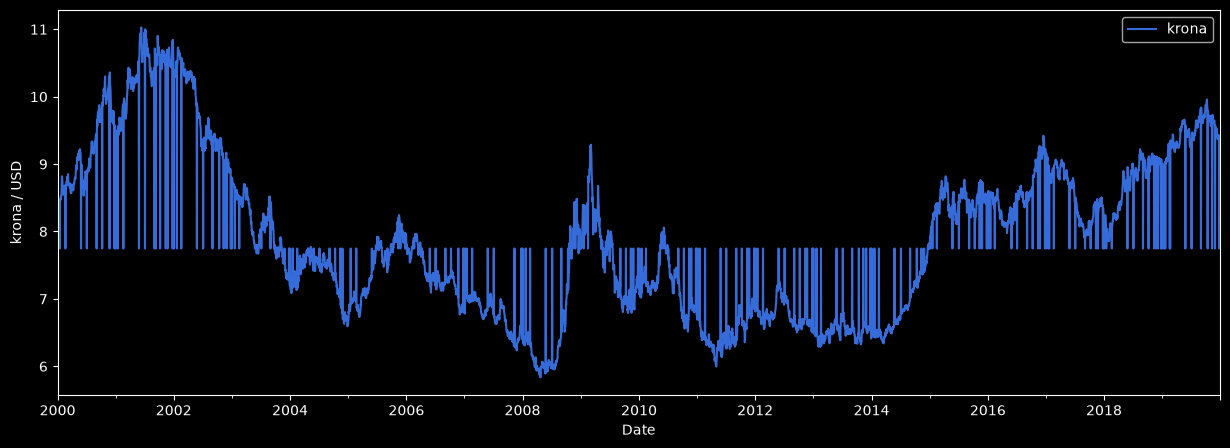

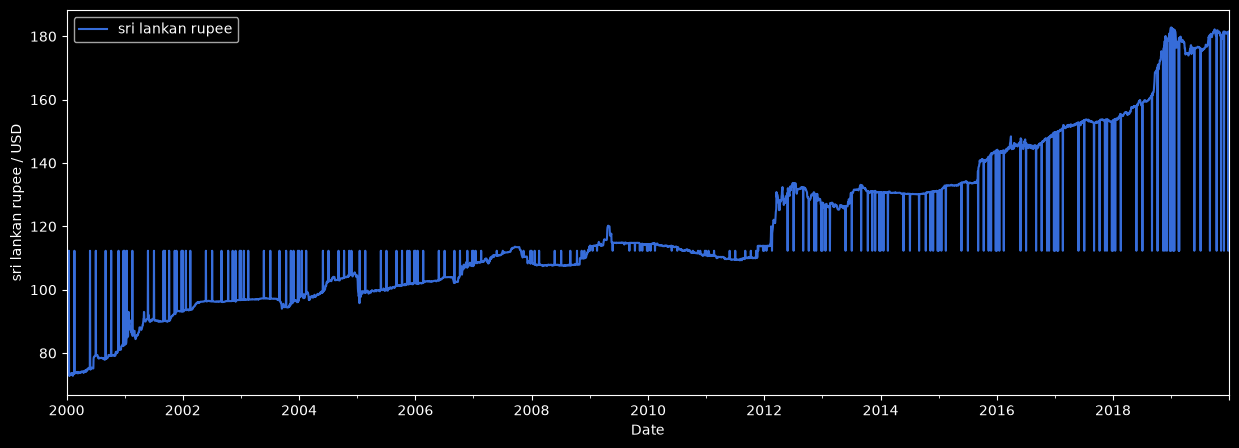

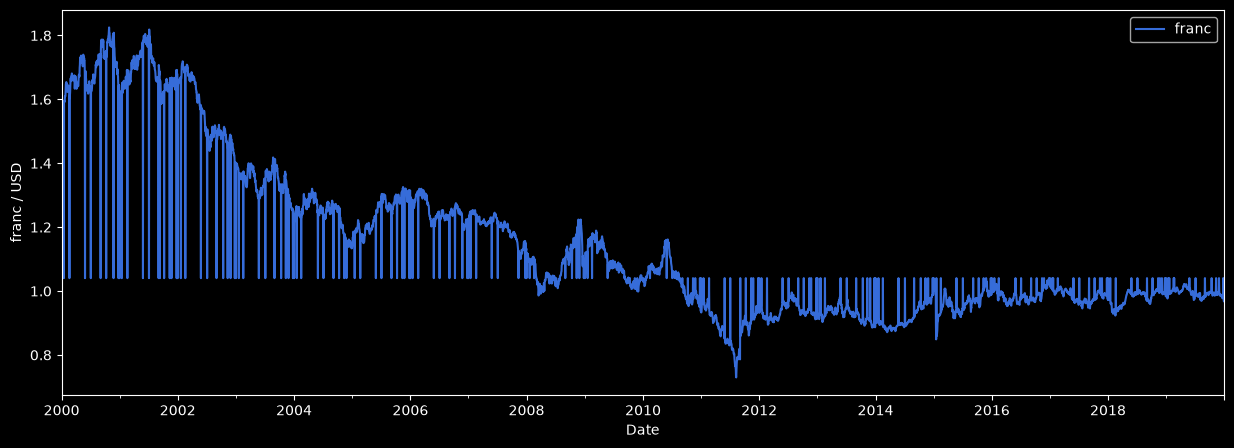

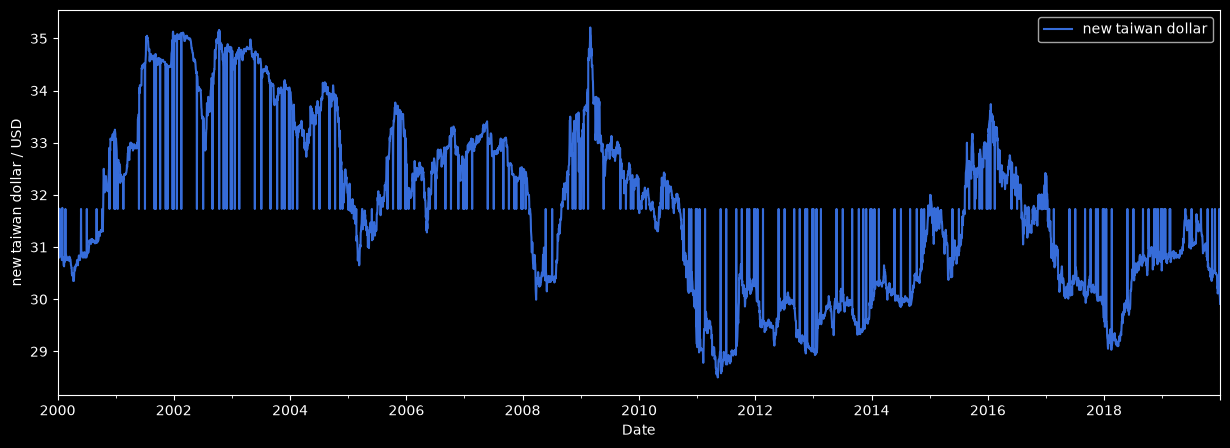

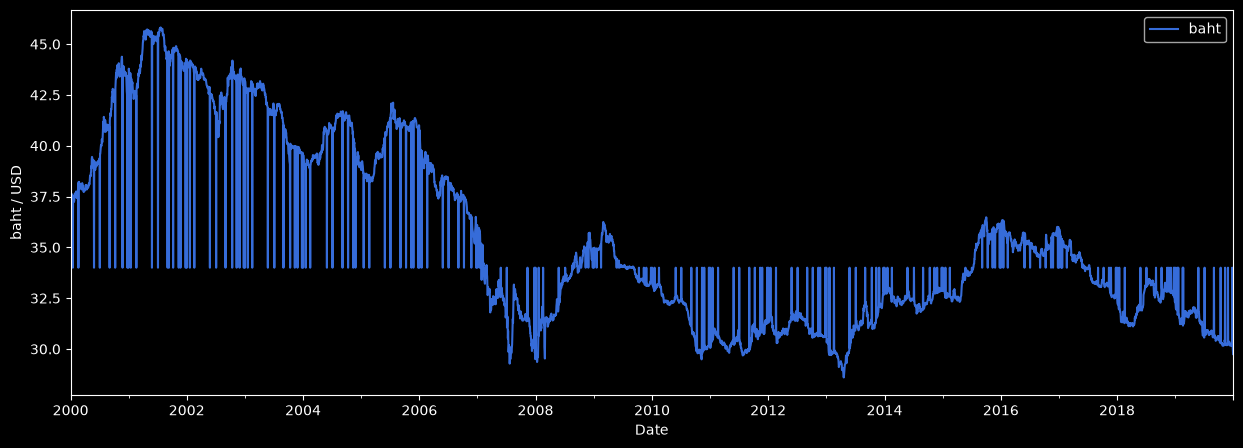

In [119]:
# now let's plot the graphs for each currency
for col in currency_cols:
    plot_currency_against_time(df, col)

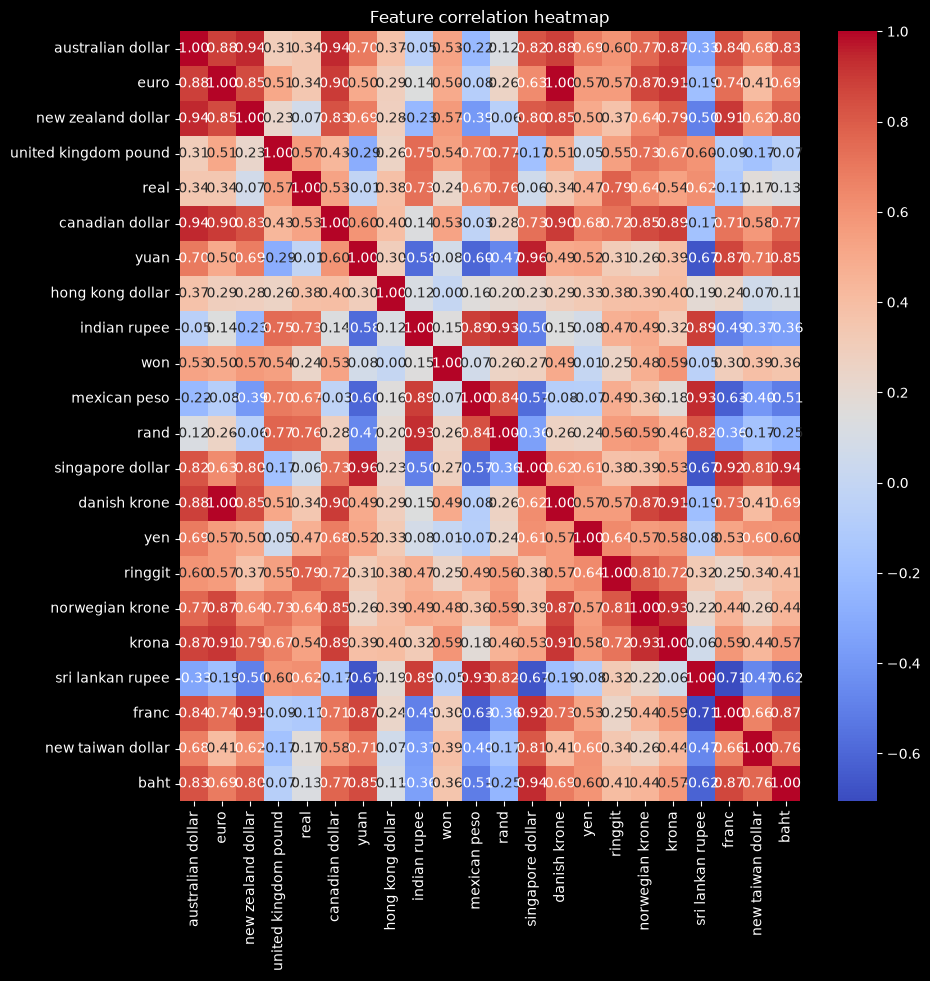

In [120]:
# Feature correlation heatmap
numeric_df = df.select_dtypes(include = ["number"])
plt.figure(figsize = (10,10))
sns.heatmap(data = numeric_df.corr(), annot = True, fmt = ".2f", cmap = "coolwarm")
plt.title("Feature correlation heatmap")
plt.show()

<Figure size 1500x500 with 0 Axes>

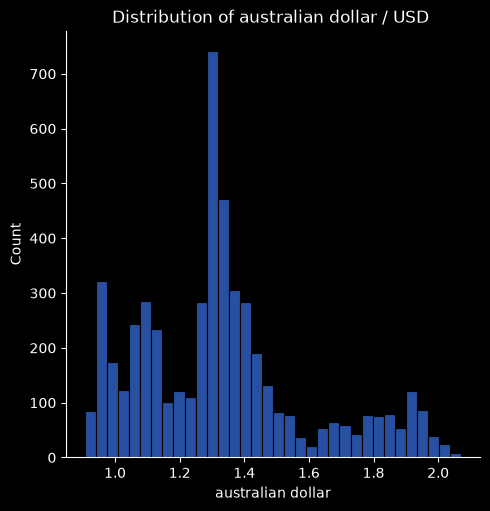

<Figure size 1500x500 with 0 Axes>

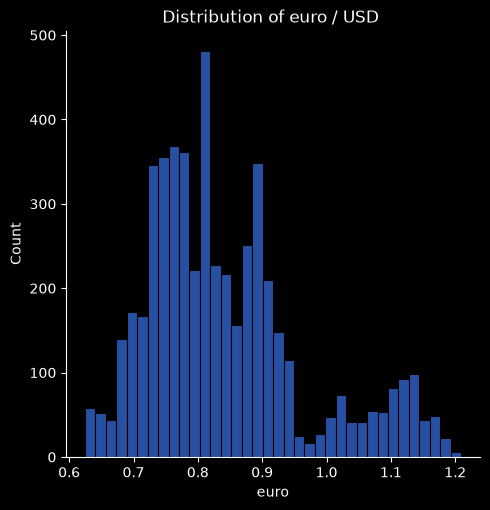

<Figure size 1500x500 with 0 Axes>

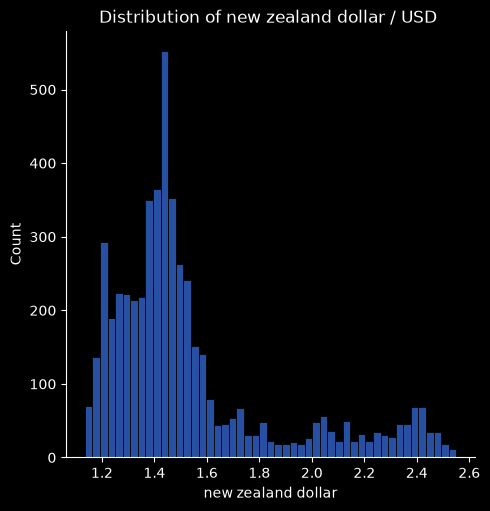

<Figure size 1500x500 with 0 Axes>

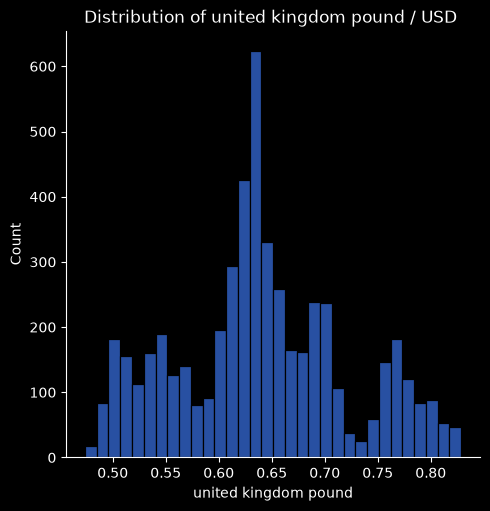

<Figure size 1500x500 with 0 Axes>

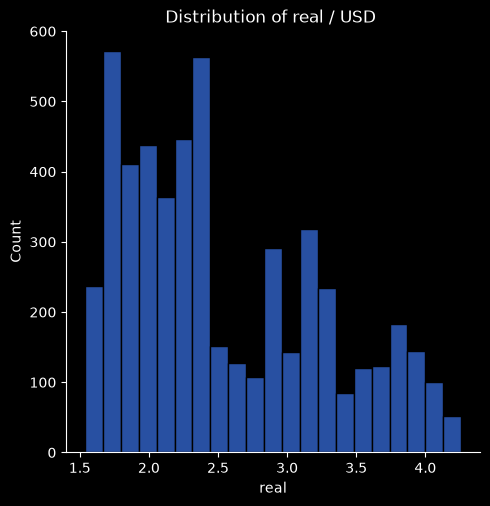

<Figure size 1500x500 with 0 Axes>

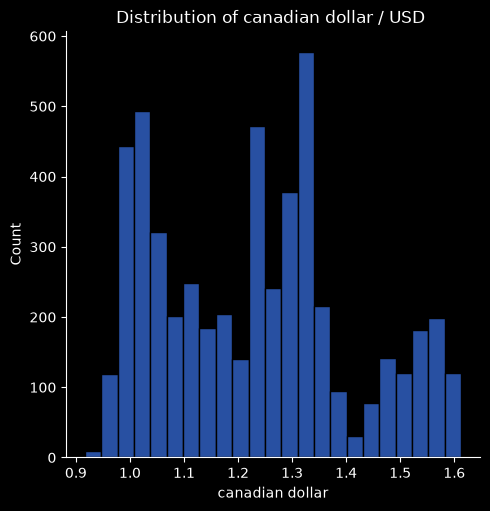

<Figure size 1500x500 with 0 Axes>

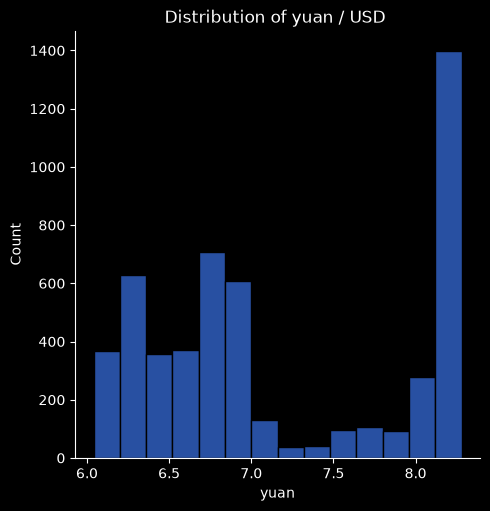

<Figure size 1500x500 with 0 Axes>

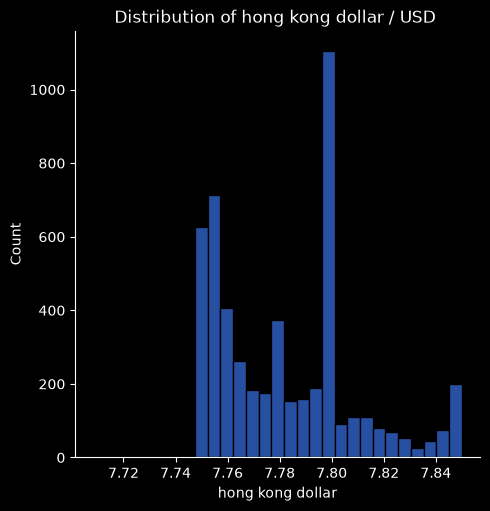

<Figure size 1500x500 with 0 Axes>

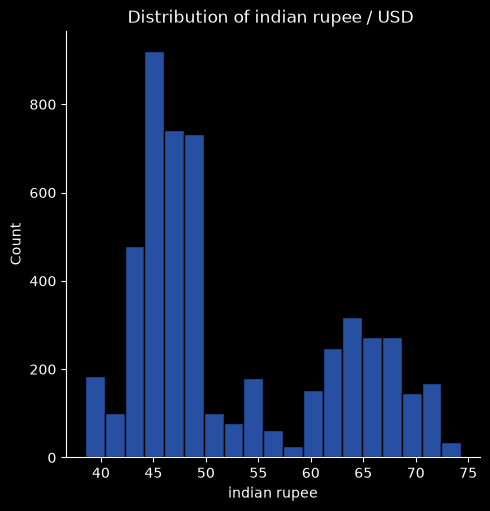

<Figure size 1500x500 with 0 Axes>

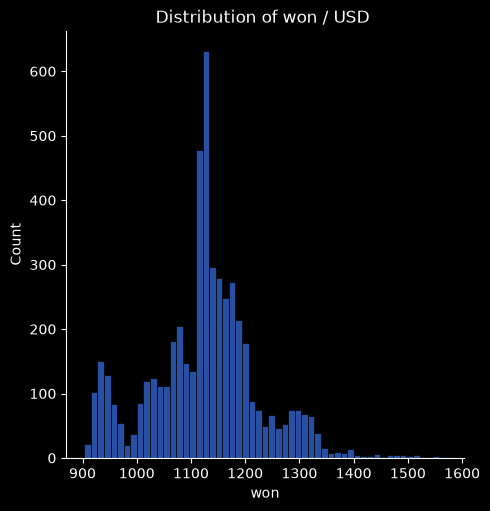

<Figure size 1500x500 with 0 Axes>

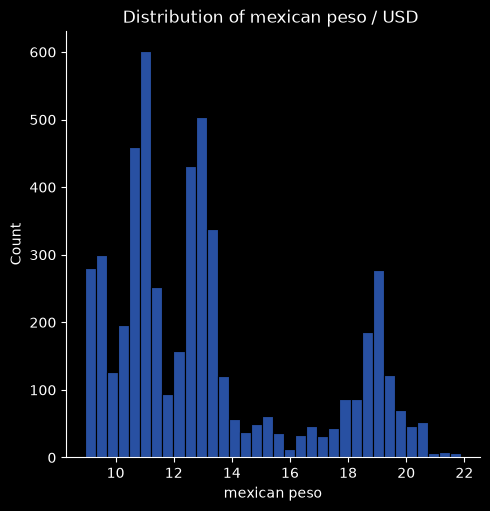

<Figure size 1500x500 with 0 Axes>

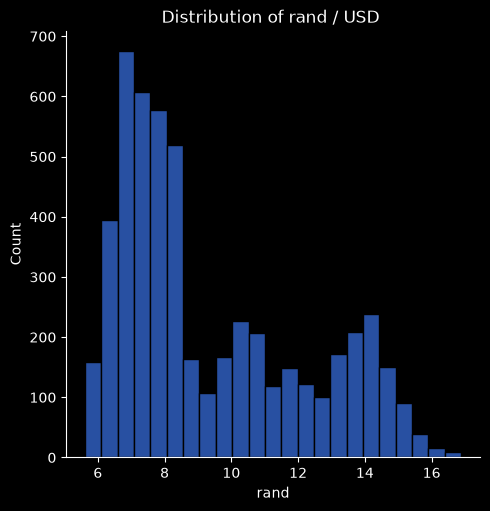

<Figure size 1500x500 with 0 Axes>

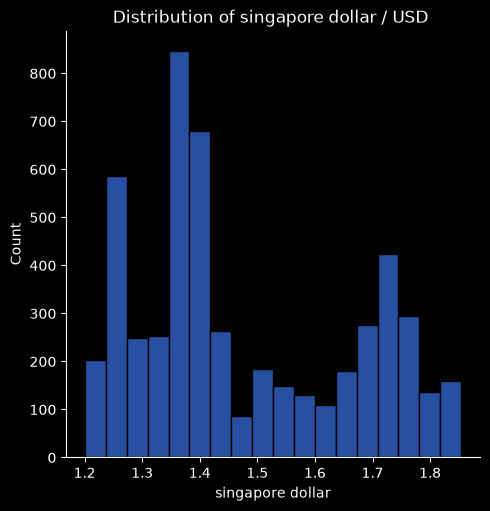

<Figure size 1500x500 with 0 Axes>

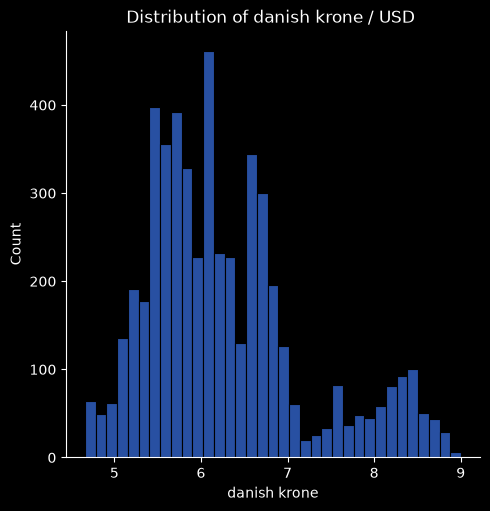

<Figure size 1500x500 with 0 Axes>

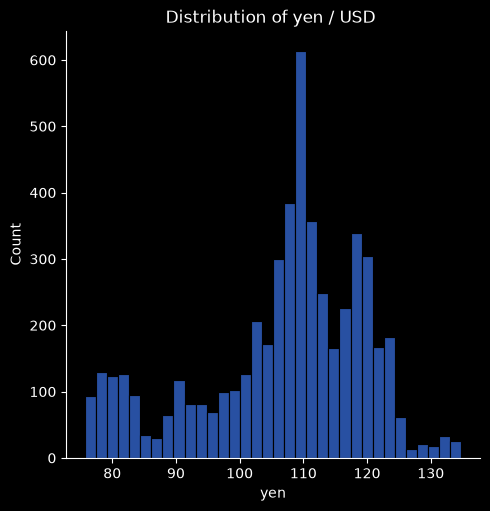

<Figure size 1500x500 with 0 Axes>

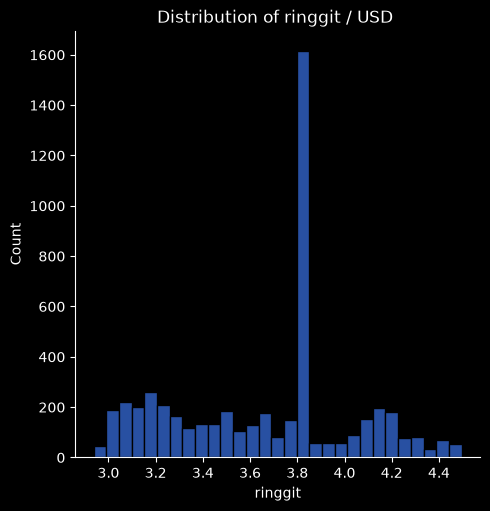

<Figure size 1500x500 with 0 Axes>

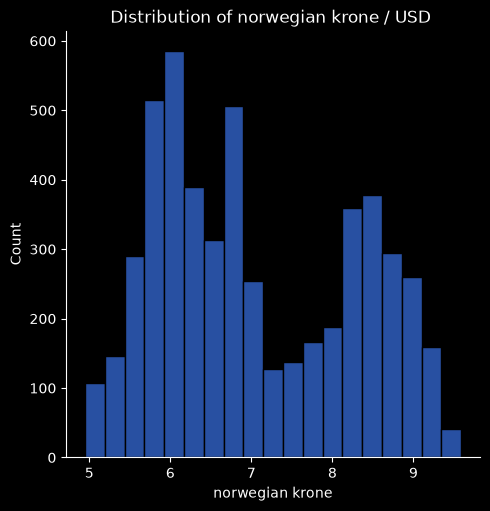

<Figure size 1500x500 with 0 Axes>

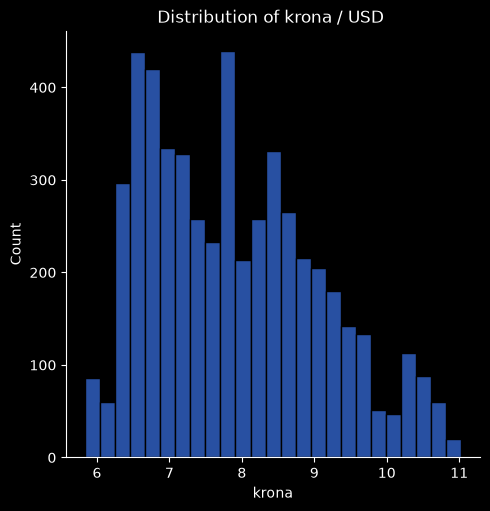

<Figure size 1500x500 with 0 Axes>

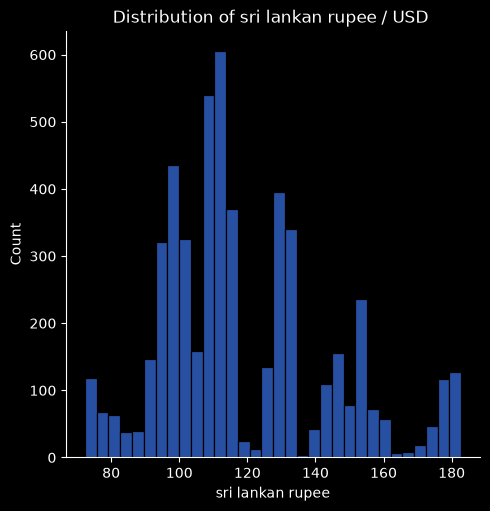

<Figure size 1500x500 with 0 Axes>

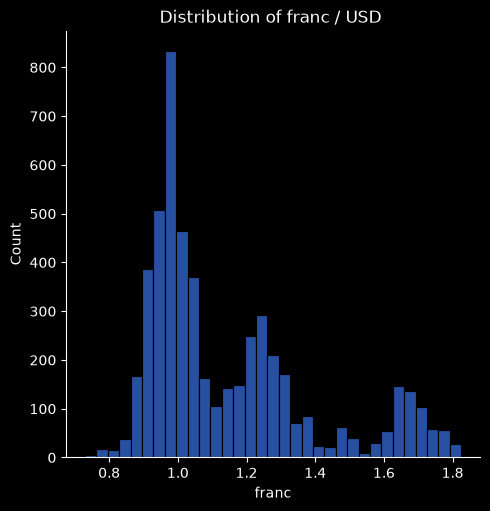

<Figure size 1500x500 with 0 Axes>

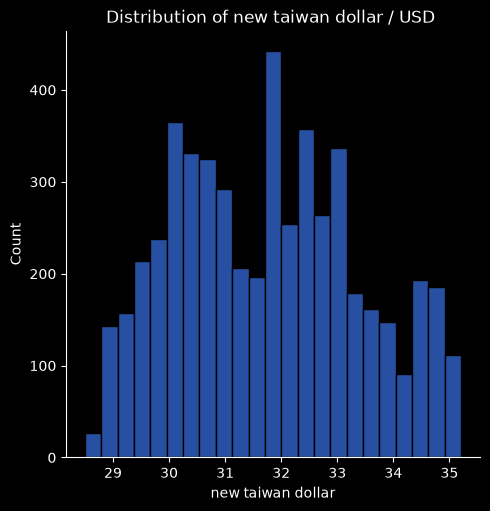

<Figure size 1500x500 with 0 Axes>

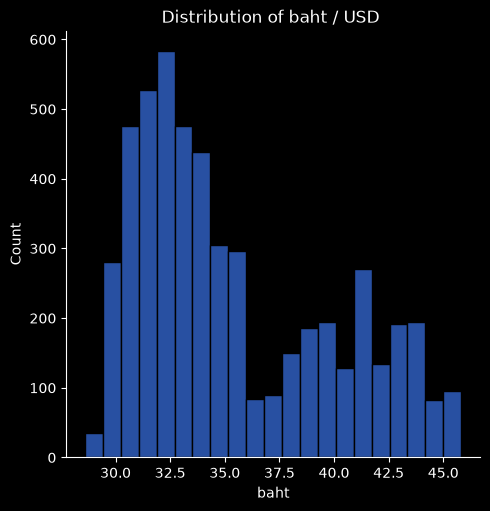

In [121]:
# distribution plots of all currencies (taking away the order, and investigating over the whole time period)
for col in currency_cols:
    plt.figure(figsize = (15,5))
    sns.displot(data = df[col])
    plt.title("Distribution of " + col + " / USD ")
    plt.show()


In [122]:
from tensorflow.keras.callbacks import EarlyStopping
from keras.src.layers import InputLayer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from autots import AutoTS
from statsmodels.tsa.arima.model import ARIMA
### PREDICTIVE MODELLING ###
# train test split, should be done chronologically as this is time series analysis
# we need to predict for each currency, let's create a function which splits into train and test
# first set date to be index to ensure that it comes in train and test sets
df.set_index("date", inplace = True)
def split_train_test(currency, window_size = 60): # let's use the recommended last 60 days as test
    train = df[currency].iloc[:-window_size]
    test = df[currency].iloc[-window_size:]
    return train, test

# we need functions now to fit and evaluate each model
## XGBOOST ##
def fit_XGBRegressor(train, test):
    model = XGBRegressor(
        n_estimators = 500,
        learning_rate = 0.1,
        max_depth = 5,
        min_child_weight = 5,
        random_state = 42
    )
    # To fit XGBoost, it needs X = features known at time t, y = value you're trying to predict at time t+1
    # Let's perform feature engineering and create features using lag values and rolling statistics
    features_train = pd.DataFrame(index = train.index)
    features_train["price"] = train

    # lagged prices
    features_train["lag_1"] = train.shift(1)
    features_train["lag_2"] = train.shift(2)
    features_train["lag_3"] = train.shift(3)
    features_train["lag_5"] = train.shift(5)
    features_train["lag_10"] = train.shift(10)

    # rolling statistics
    features_train["rolling_mean_5"] = train.rolling(5).mean()
    features_train["rolling_mean_10"] = train.rolling(10).mean()
    features_train["rolling_mean_20"] = train.rolling(20).mean()
    features_train["rolling_std_5"] = train.rolling(5).std()
    features_train["rolling_std_10"] = train.rolling(10).std()
    features_train["rolling_std_20"] = train.rolling(20).std()

    features_train["target"] = train.shift(-1) # next date's price is target
    features_train = features_train.dropna()
    X_train = features_train.drop("target", axis = 1)
    y_train = features_train["target"]

    # same for test but we want to combine train + test so that first test observations
    # have access to the historical values needed for lags and rolling stats
    history = pd.concat([train, test]) # combines train and test into 1 df
    features_test = pd.DataFrame(index = history.index)
    features_test["price"] = history

    # lagged prices
    features_test["lag_1"] = history.shift(1)
    features_test["lag_2"] = history.shift(2)
    features_test["lag_3"] = history.shift(3)
    features_test["lag_5"] = history.shift(5)
    features_test["lag_10"] = history.shift(10)

    # rolling statistics
    features_test["rolling_mean_5"] = history.rolling(5).mean()
    features_test["rolling_mean_10"] = history.rolling(10).mean()
    features_test["rolling_mean_20"] = history.rolling(20).mean()
    features_test["rolling_std_5"] = history.rolling(5).std()
    features_test["rolling_std_10"] = history.rolling(10).std()
    features_test["rolling_std_20"] = history.rolling(20).std()

    features_test["target"] = history.shift(-1)
    # NOW select only test dates
    features_test = features_test.loc[test.index]
    features_test = features_test.dropna()

    X_test = features_test.drop("target", axis = 1)
    y_test = features_test["target"]

    model.fit(X_train, y_train) # train model
    predictions = model.predict(X_test)
    return model, predictions, y_test


## LSTM RNN MODEL ## - first need to ensure X is a 2D array, y is a 1D array
def fit_LSTM(train, test, lookback = 20):
    scaler = MinMaxScaler() # LSTM works better with scaled normalised data
    train_scaled = scaler.fit_transform(train.to_numpy().reshape(-1,1))
    history = pd.concat([train, test])
    history_scaled = scaler.transform(history.to_numpy().reshape(-1,1))

    X_train = []
    y_train = []
    for index in range(lookback, len(train_scaled)):
        X_train.append(train_scaled[index - lookback : index])
        y_train.append(train_scaled[index])
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    X_test = []
    y_test = []
    test_start = len(train)
    for index in range(test_start, len(history_scaled)):
        X_test.append(history_scaled[index - lookback : index])
        y_test.append(history_scaled[index])
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    # create 3 layered stacked LSTM model
    n_features = 1 # only using 1 input variable (currency) for forecast
    model = Sequential()
    model.add(InputLayer((lookback, n_features)))
    model.add(LSTM(units = 100, return_sequences = True))
    model.add(LSTM(units = 100, return_sequences = True))
    model.add(LSTM(units = 50))
    model.add(Dense(units = 8, activation = "relu"))
    model.add(Dense(units = 1, activation = "linear"))

    model.compile(optimizer = "adam", loss = "mse", metrics = ["mae"])
    model.fit(
        X_train,
        y_train,
        epochs = 50,
        batch_size = 32,
        verbose = 0
    )

    predictions_scaled = model.predict(X_test, verbose = 0)
    predictions = scaler.inverse_transform(predictions_scaled).flatten() # convert back to original scale
    y_test_original = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
    return model, predictions, y_test_original

## AutoTS ## - needs input as df, not series
def fit_AutoTS(train, test): # automated time series - tries different forecasting approaches and selects model based on val performance
    train_df = train.to_frame(name = "value")
    model = AutoTS(
        forecast_length = len(test), # forecast next 60 observations, test window
        frequency = "infer",
        ensemble = "simple",
        model_list = "fast",
        verbose = 0
    )
    model = model.fit(train_df)
    predictions = model.predict() # autoTS does not need testing data to predict on, it just predicts the next forecast_length points
    forecast_df = predictions.forecast # df of predicted values
    predictions = forecast_df["value"].values
    y_test = test.values
    return model, predictions, y_test

## ARIMA ## - AutoRegressive Integrated Moving Average
# 3 components: ARIMA(p,d,q) where:
# p = autoregressive component, determines how many previous observations are used
# d = differencing, how many times the series is differenced to make it stationary
# q = moving-average component, controls the moving-average/error component
def fit_ARIMA(train, test):
    model = ARIMA(
        train,
        order = (2,1,2)
    )
    model_fit = model.fit()
    predictions = model_fit.forecast(steps = len(test)).values
    y_test = test.values
    return model_fit, predictions, y_test


# evaluate model function, takes in dictionary of models (see below)
def evaluate_models_performance(models):
    metrics = []
    for name, model_list in models.items():
        # these metrics may only be for XGBoost, might have to put if statement here if model is xgboost then do this...
        metrics.append({
            "Model" : name,
            "MAE" : mean_absolute_error(model_list[1], model_list[2]),
            "RMSE" : np.sqrt(mean_squared_error(model_list[1], model_list[2])),
            "R^2" : r2_score(model_list[1], model_list[2])
        }
        )

for currency in currency_cols:
    models = {} # models will be a dictionary where key is name of model, value is list of model, test, prediction
    train, test = split_train_test(currency, window_size = 60)
    # XGBoost
    model_xgbr, y_pred_xgbr, y_test_xgbr = fit_XGBRegressor(train, test)
    models.update({
        "XGBRegressor" : [model_xgbr, y_test_xgbr, y_pred_xgbr]
    })
    # LSTM
    model_lstm, y_pred_lstm, y_test_lstm = fit_LSTM(train, test)
    models.update({
        "LSTM" : [model_lstm, y_test_lstm, y_pred_lstm]
    })
    # AutoTS
    model_autoTS, y_pred_autoTS, y_test_autoTS = fit_AutoTS(train, test)
    models.update({
        "AutoTS" : [model_autoTS, y_test_autoTS, y_pred_autoTS]
    })
    # ARIMA
    model_ARIMA, y_pred_ARIMA, y_test_ARIMA = fit_ARIMA(train, test)
    models.update({
        "ARIMA" : [model_ARIMA, y_test_ARIMA, y_pred_ARIMA]
    })



